***ARUN***


In [7]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)

features_df = pd.read_csv("Features_volatility.csv")
features_df["date"] = pd.to_datetime(features_df["date"])
features_df = features_df.set_index("date")

feature_cols = [
    "global_vol", "vol_slope", "vov",
    "SPY_return", "QQQ_return",
    "SPY_vol_12", "SPY_vol_4", "SPY_momentum_12",
    "VIX", "VIX_change",
    "TREASURY_10Y", "TREASURY_2Y", "yield_spread",
]

print("features_df loaded")
print(features_df[feature_cols].head())
print()
print("Date range:", features_df.index.min(), "to", features_df.index.max())
print("Rows:", len(features_df))


regime_df = pd.read_parquet("regime_labeled_k3.parquet").sort_index()
regime_df["regime_name"] = regime_df["regime_name"].replace({
    "0": "Opportunity",
    "1": "Normal",
    "2": "Stress"
})
print()
print("regime_df loaded")
print(regime_df[["regime", "regime_name"]].head())
print()
print("Regime counts:")
print(regime_df["regime_name"].value_counts(dropna=False))

# Build modeling dataframe
model_df = features_df[feature_cols].copy()
model_df["target"] = regime_df["regime_name"].reindex(model_df.index).shift(-1)
model_df.dropna(inplace=True)

print(f"Modeling rows: {len(model_df):,}")
print(f"Date range: {model_df.index.min().date()} to {model_df.index.max().date()}")
print()
print("Target class counts:")
print(model_df['target'].value_counts())
print()

# Chronological split
TRAIN_END = '2010-12-31'
TEST_START = '2011-01-01'

train = model_df.loc[:TRAIN_END]
test = model_df.loc[TEST_START:]

X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']

print(f"Training rows: {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Testing rows:  {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")
print()

for split_name, y in [("Train", y_train), ("Test", y_test)]:
    print(f"{split_name} class distribution:")
    print(y.value_counts(normalize=True).round(3))
    print()

# Scale data only for logistic regression
from sklearn.preprocessing import StandardScaler

sup_scaler = StandardScaler()
X_train_sc = sup_scaler.fit_transform(X_train)
X_test_sc = sup_scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("LOGISTIC REGRESSION - Out-of-sample performance")
print(classification_report(y_test, y_pred_lr, digits=3))
print()

# naive persistence model
persistence_pred = y_test.shift(1).fillna(method="bfill")

print("Persistence baseline accuracy:",
      (persistence_pred == y_test).mean())

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST - Out-of-sample performance")
print(classification_report(y_test, y_pred_rf, digits=3))
print()


# Confusion matrices
class_order = ['Opportunity', 'Normal', 'Stress']

models_to_plot = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
]


n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices - Test Set (2011-present)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary metrics
rows = []
for name, y_pred in models_to_plot:
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (weighted)": round(
            precision_score(y_test, y_pred, average='weighted', zero_division=0), 4
        ),
        "Recall (weighted)": round(
            recall_score(y_test, y_pred, average='weighted', zero_division=0), 4
        ),
    })

summary_df = pd.DataFrame(rows).set_index("Model")
print("Model summary:")
print(summary_df.to_string())
print()

# Feature interpretation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic regression coefficients
ax0 = axes[0]

if len(lr.classes_) == 2:
    # For binary logistic regression, sklearn stores one coefficient vector:
    # class_1 relative to class_0
    coef_s = pd.Series(
        lr.coef_[0],
        index=feature_cols,
        name=f"{lr.classes_[1]} vs {lr.classes_[0]}"
    ).sort_values()

    coef_s.plot(kind="barh", ax=ax0, color="steelblue", alpha=0.8)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title(f"Logistic Regression Coefficients\n({lr.classes_[1]} vs {lr.classes_[0]})")
    ax0.set_xlabel("Coefficient")
else:
    coef_df = pd.DataFrame(lr.coef_, columns=feature_cols, index=lr.classes_)
    colors = ["steelblue", "darkorange", "green", "purple", "red"]

    feature_order = np.argsort(np.abs(coef_df.values).mean(axis=0))
    ordered_features = np.array(feature_cols)[feature_order]

    for i, cls in enumerate(lr.classes_):
        vals = coef_df.loc[cls, ordered_features]
        ax0.barh(
            np.arange(len(ordered_features)) + i * 0.25,
            vals,
            height=0.25,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=cls
        )

    ax0.set_yticks(np.arange(len(ordered_features)) + 0.25)
    ax0.set_yticklabels(ordered_features, fontsize=9)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title("Logistic Regression Coefficients (per class)")
    ax0.legend(fontsize=9)

# Random forest feature importance
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
fi.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title("Random Forest - Feature Importances")
axes[1].set_xlabel("Mean Decrease in Impurity")

plt.suptitle("Feature Interpretation", fontsize=13)
plt.tight_layout()
plt.show()

# Simple lookahead-bias sanity checks
assert (X_train.index < pd.Timestamp(TEST_START)).all()
assert (X_test.index >= pd.Timestamp(TEST_START)).all()
assert model_df.index.equals(model_df.index.sort_values())
assert not X_train.isna().any().any()
assert not X_test.isna().any().any()

features_df loaded
            global_vol  vol_slope       vov  SPY_return  QQQ_return  \
date                                                                  
2004-11-26    0.017904  -0.002760  0.002622    0.007921    0.013702   
2004-12-03    0.017909  -0.006027  0.002257    0.007605    0.023463   
2004-12-10    0.017488  -0.003261  0.002410    0.000671   -0.004984   
2004-12-17    0.016667  -0.002127  0.002522    0.005650   -0.002052   
2004-12-24    0.016023  -0.001375  0.002586    0.011135    0.007347   

            SPY_vol_12  SPY_vol_4  SPY_momentum_12    VIX  VIX_change  \
date                                                                    
2004-11-26    0.017007   0.018439         0.063100  12.78   -0.053333   
2004-12-03    0.016996   0.009352         0.062279  12.96    0.014085   
2004-12-10    0.017046   0.007760         0.057744  12.76   -0.015432   
2004-12-17    0.015872   0.003348         0.079848  11.95   -0.063480   
2004-12-24    0.015417   0.004366         0.0

ValueError: At least one label specified must be in y_true

## \#\# Using Arun's foundation and  updated unsupervised target regime to see results\.

regime labeled sc, added spy lag vix lag, spread lad

features_df loaded
            SPY_return  QQQ_return  SPY_momentum_12  VIX_change  SPY_vol_4  \
date                                                                         
2004-11-26    0.007921    0.013702         0.063100   -0.053333   0.018439   
2004-12-03    0.007605    0.023463         0.062279    0.014085   0.009352   
2004-12-10    0.000671   -0.004984         0.057744   -0.015432   0.007760   
2004-12-17    0.005650   -0.002052         0.079848   -0.063480   0.003348   
2004-12-24    0.011135    0.007347         0.070833   -0.060251   0.004366   

            SPY_vol_12  yield_spread  SPY_return_lag1  SPY_return_lag2  \
date                                                                     
2004-11-26    0.017007          1.21              NaN              NaN   
2004-12-03    0.016996          1.33         0.007921              NaN   
2004-12-10    0.017046          1.21         0.007605         0.007921   
2004-12-17    0.015872          1.18         0.000671         0.

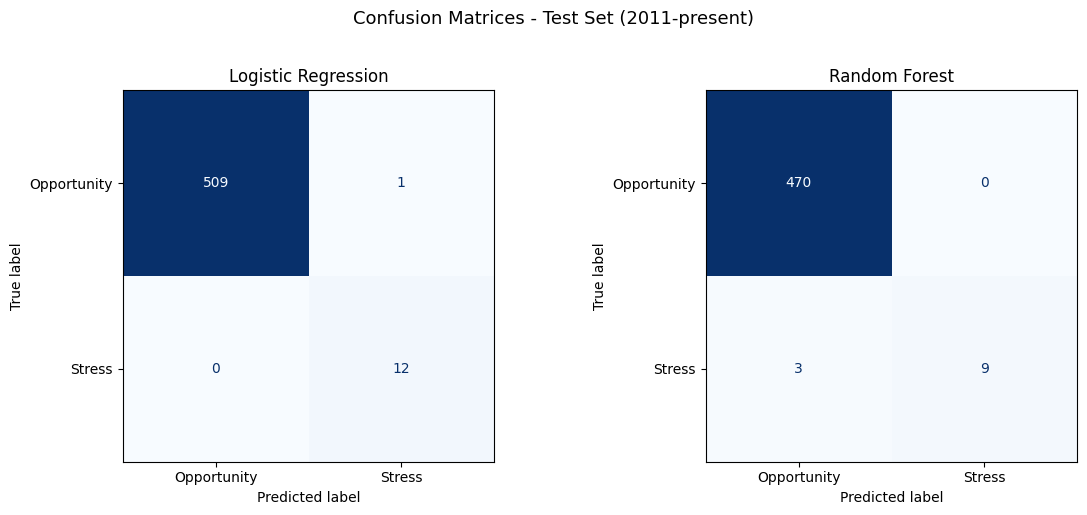

Model summary:
                      Accuracy  Precision (weighted)  Recall (weighted)
Model                                                                  
Majority Baseline       0.7781                0.6054             0.7781
Persistence Baseline    0.9419                0.9419             0.9419
Logistic Regression     0.8005                0.8412             0.8005
Random Forest           0.7279                0.7504             0.7279



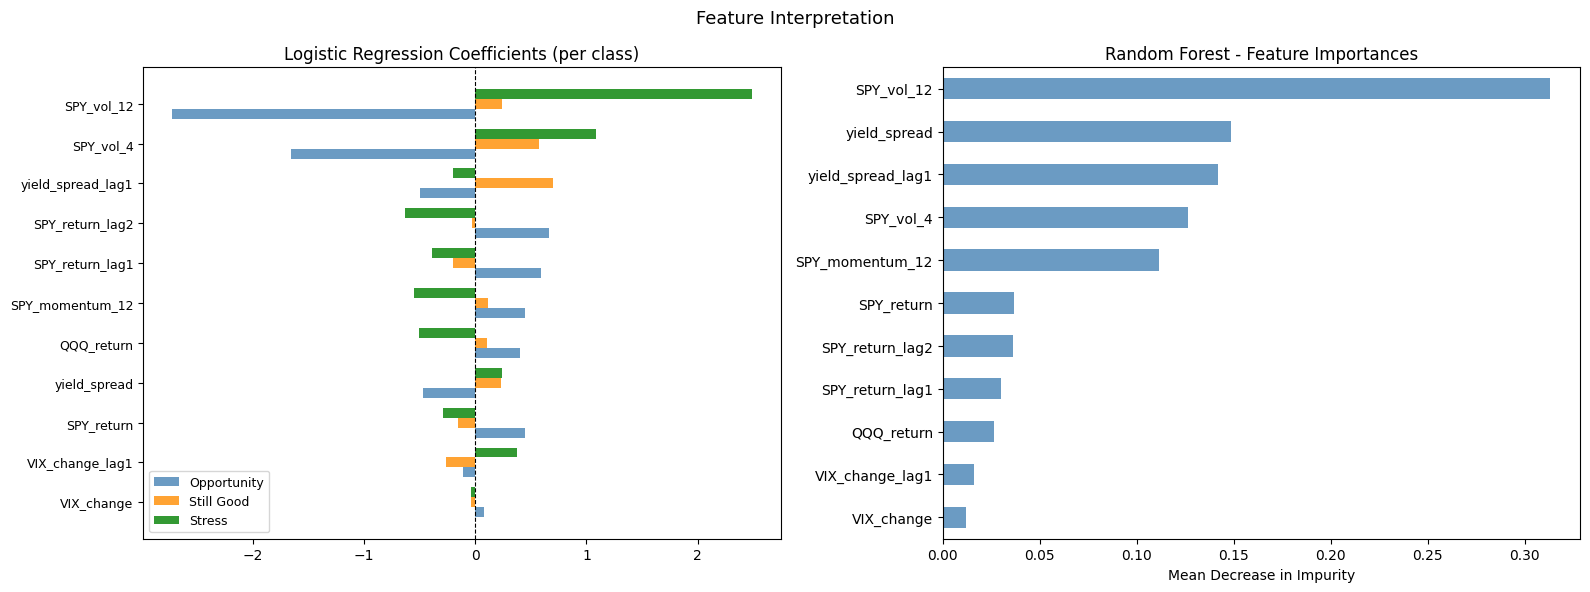

In [1]:
## Spencer: Same as above, wanted to test new broken up logic


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)



# Step 1: Load and prepare features
features_df = pd.read_csv("Features_volatility.csv")
features_df["date"] = pd.to_datetime(features_df["date"])
features_df = features_df.sort_values("date").set_index("date")

# Lagged predictors
features_df["SPY_return_lag1"] = features_df["SPY_return"].shift(1)
features_df["SPY_return_lag2"] = features_df["SPY_return"].shift(2)
features_df["VIX_change_lag1"] = features_df["VIX_change"].shift(1)
features_df["yield_spread_lag1"] = features_df["yield_spread"].shift(1)

# Predictive feature set
predict_cols = [
    "SPY_return",
    "QQQ_return",
    "SPY_momentum_12",
    "VIX_change",
    "SPY_vol_4",
    "SPY_vol_12",
    "yield_spread",
    "SPY_return_lag1",
    "SPY_return_lag2",
    "VIX_change_lag1",
    "yield_spread_lag1"
]

print("features_df loaded")
print(features_df[predict_cols].head())
print()
print("Date range:", features_df.index.min(), "to", features_df.index.max())
print("Rows:", len(features_df))


# Step 2: Load regime labels
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet").sort_index()

# Align both datasets on common dates
common_idx = features_df.index.intersection(regime_df.index)
features_df = features_df.loc[common_idx].copy()
regime_df = regime_df.loc[common_idx].copy()


# Step 3: Create current regime name from 3-class labels
regime_df["regime_name"] = regime_df["regime_3class"].map({
    0: "Opportunity",
    1: "Still Good",
    2: "Stress"
})

# Next-period target
regime_df["target_regime"] = regime_df["regime_3class"].shift(-1)

regime_df["target_regime_name"] = regime_df["target_regime"].map({
    0: "Opportunity",
    1: "Still Good",
    2: "Stress"
})

class_order = ["Opportunity", "Still Good", "Stress"]

print()
print("regime_df loaded")
print(
    regime_df[
        ["regime", "regime_3class", "regime_name", "target_regime", "target_regime_name"]
    ].head()
)
print()
print("Current regime counts:")
print(regime_df["regime_name"].value_counts(dropna=False))
print()
print("Target regime counts:")
print(regime_df["target_regime_name"].value_counts(dropna=False))

# Step 4: Build final supervised dataset

model_df = features_df[predict_cols].copy()
model_df["target"] = regime_df["target_regime_name"].reindex(model_df.index)

# Drop rows with missing predictors or target
model_df = model_df.dropna().copy()

print()
print(f"Modeling rows: {len(model_df):,}")
print(f"Date range: {model_df.index.min().date()} to {model_df.index.max().date()}")
print()
print("Target class counts:")
print(model_df["target"].value_counts())
print()


TRAIN_END = "2010-12-31"
TEST_START = "2011-01-01"

train = model_df.loc[:TRAIN_END]
test = model_df.loc[TEST_START:]

X_train, y_train = train[predict_cols], train["target"]
X_test, y_test = test[predict_cols], test["target"]

majority_class = y_train.value_counts().idxmax()

majority_pred = pd.Series(
    [majority_class] * len(y_test),
    index=y_test.index
)

majority_acc = accuracy_score(y_test, majority_pred)

print("Majority baseline accuracy:", round(majority_acc, 4))


print(f"Training rows: {len(train):,} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Testing rows:  {len(test):,} ({test.index.min().date()} to {test.index.max().date()})")
print()

for split_name, y in [("Train", y_train), ("Test", y_test)]:
    print(f"{split_name} class distribution:")
    print(y.value_counts(normalize=True).round(3))
    print()



sup_scaler = StandardScaler()
X_train_sc = sup_scaler.fit_transform(X_train)
X_test_sc = sup_scaler.transform(X_test)



lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight = 'balanced'
)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("LOGISTIC REGRESSION - Out-of-sample performance")
print(classification_report(y_test, y_pred_lr, digits=3))
print()



persistence_pred = y_test.shift(1)
persistence_pred.iloc[0] = y_train.iloc[-1]


persistence_acc = accuracy_score(y_test, persistence_pred)

print("Persistence baseline accuracy:", round(persistence_acc, 4))



rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    class_weight = 'balanced'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST - Out-of-sample performance")
print(classification_report(y_test, y_pred_rf, digits=3))
print()



class_order = ["Opportunity", "Stress"]

models_to_plot = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
]

n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, y_pred, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices - Test Set (2011-present)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



rows = []

# Majority baseline
rows.append({
    "Model": "Majority Baseline",
    "Accuracy": round(accuracy_score(y_test, majority_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, majority_pred, average="weighted", zero_division=0), 4
    ),
})

# Persistence baseline
rows.append({
    "Model": "Persistence Baseline",
    "Accuracy": round(accuracy_score(y_test, persistence_pred), 4),
    "Precision (weighted)": round(
        precision_score(y_test, persistence_pred, average="weighted", zero_division=0), 4
    ),
    "Recall (weighted)": round(
        recall_score(y_test, persistence_pred, average="weighted", zero_division=0), 4
    ),
})

# ML models
for name, y_pred in models_to_plot:
    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (weighted)": round(
            precision_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
        "Recall (weighted)": round(
            recall_score(y_test, y_pred, average="weighted", zero_division=0), 4
        ),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

print("Model summary:")
print(summary_df.to_string())
print()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic regression coefficients
ax0 = axes[0]

if len(lr.classes_) == 2:
    coef_s = pd.Series(
        lr.coef_[0],
        index=predict_cols,
        name=f"{lr.classes_[1]} vs {lr.classes_[0]}"
    ).sort_values()

    coef_s.plot(kind="barh", ax=ax0, color="steelblue", alpha=0.8)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title(f"Logistic Regression Coefficients\n({lr.classes_[1]} vs {lr.classes_[0]})")
    ax0.set_xlabel("Coefficient")
else:
    coef_df = pd.DataFrame(lr.coef_, columns=predict_cols, index=lr.classes_)
    colors = ["steelblue", "darkorange", "green", "purple", "red"]

    feature_order = np.argsort(np.abs(coef_df.values).mean(axis=0))
    ordered_features = np.array(predict_cols)[feature_order]

    for i, cls in enumerate(lr.classes_):
        vals = coef_df.loc[cls, ordered_features]
        ax0.barh(
            np.arange(len(ordered_features)) + i * 0.25,
            vals,
            height=0.25,
            color=colors[i % len(colors)],
            alpha=0.8,
            label=cls
        )

    ax0.set_yticks(np.arange(len(ordered_features)) + 0.25)
    ax0.set_yticklabels(ordered_features, fontsize=9)
    ax0.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax0.set_title("Logistic Regression Coefficients (per class)")
    ax0.legend(fontsize=9)

# Random forest feature importance
fi = pd.Series(rf.feature_importances_, index=predict_cols).sort_values()
fi.plot(kind="barh", ax=axes[1], color="steelblue", alpha=0.8)
axes[1].set_title("Random Forest - Feature Importances")
axes[1].set_xlabel("Mean Decrease in Impurity")

plt.suptitle("Feature Interpretation", fontsize=13)
plt.tight_layout()
plt.show()



assert (X_train.index < pd.Timestamp(TEST_START)).all()
assert (X_test.index >= pd.Timestamp(TEST_START)).all()
assert model_df.index.equals(model_df.index.sort_values())
assert not X_train.isna().any().any()
assert not X_test.isna().any().any()

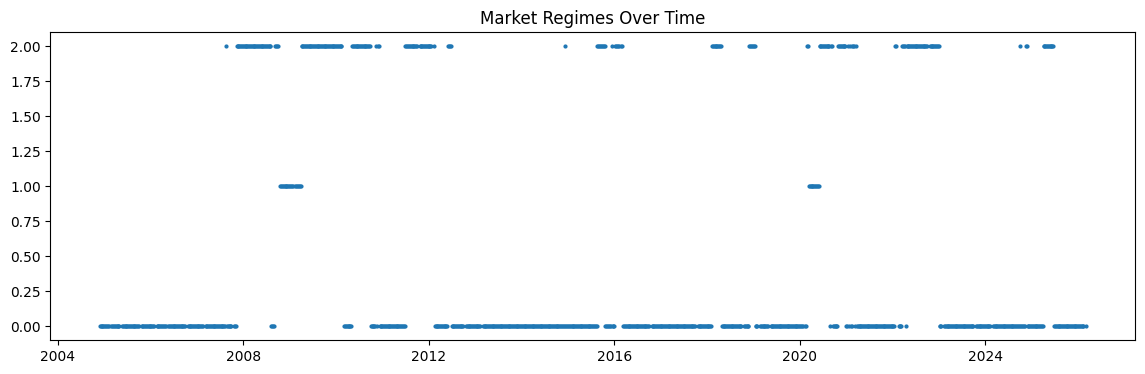

In [2]:
plt.figure(figsize=(14,4))
plt.scatter(regime_df.index, regime_df["regime"], s=4)
plt.title("Market Regimes Over Time")
plt.show()

In [3]:
pd.crosstab(
    regime_df["regime"],
    regime_df["regime_3class"],
    normalize="index"
)

regime_3class,0,1,2
regime,,,
0.0,1.0,0.0,0.0
1.0,0.0,0.0,1.0
2.0,0.0,1.0,0.0


In [4]:
baseline_pred = regime_df["regime_name"].shift(0)
baseline_pred = baseline_pred.loc[y_test.index]

accuracy_score(y_test, baseline_pred)

0.9418758256274768

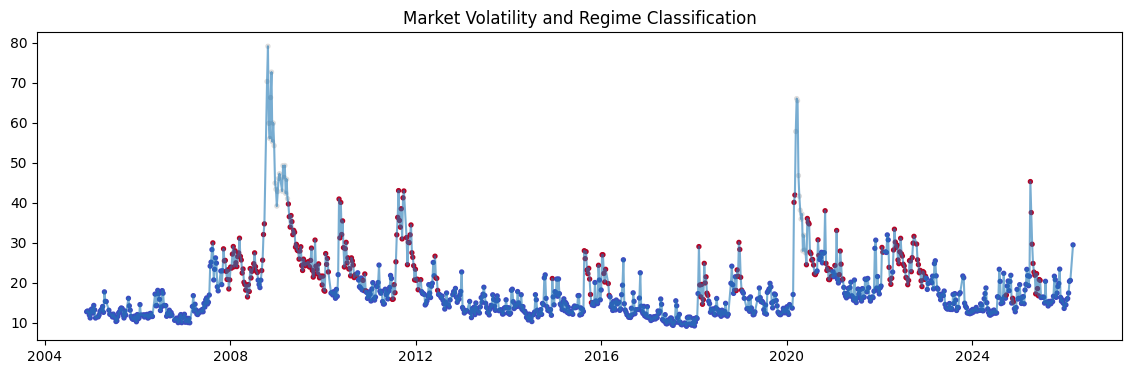

In [5]:
plt.figure(figsize=(14,4))
plt.plot(regime_df.index, regime_df["VIX"], alpha=0.6)

plt.scatter(
    regime_df.index,
    regime_df["VIX"],
    c=regime_df["regime"],
    cmap="coolwarm",
    s=8
)

plt.title("Market Volatility and Regime Classification")
plt.show()

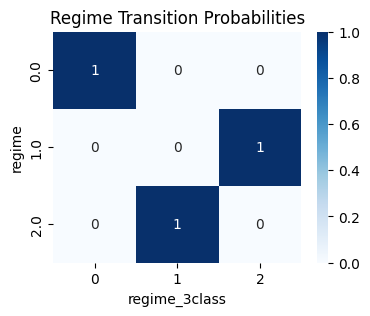

In [7]:
import seaborn as sns
transition = pd.crosstab(
    regime_df["regime"],
    regime_df["regime_3class"],
    normalize="index"
)

plt.figure(figsize=(4,3))
sns.heatmap(transition, annot=True, cmap="Blues")
plt.title("Regime Transition Probabilities")
plt.show()

In [7]:
#regime_df

# PHUC'S PART FROM ARUN AND SPENCER RUN \(2 LAYER\)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>